# 1. HM3D top-down trajectories in the same Habitat environment

질문: 같은 Habitat environment(scene) 안에서 expert trajectories가 실제 top-down space에서 구분되는가?

이 notebook은 manifest에 없는 pose를 Habitat simulator replay로 다시 얻습니다. 같은 selected trajectory id와 color를 이후 latent notebooks에서도 그대로 사용합니다.

In [1]:
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt

from pathlib import Path
import sys

repo_root = None
for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (candidate / "pyproject.toml").is_file() and (candidate / "analysis").is_dir():
        repo_root = candidate
        break
if repo_root is None:
    raise RuntimeError("Run this notebook inside the TopoVLM repository.")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import importlib
from analysis.code import hm3d_trajectory_notebook
hm3d_trajectory_notebook = importlib.reload(hm3d_trajectory_notebook)

DEFAULT_DATA_ROOT = hm3d_trajectory_notebook.DEFAULT_DATA_ROOT
plot_habitat_topdown = hm3d_trajectory_notebook.plot_habitat_topdown
replay_habitat_topdown = hm3d_trajectory_notebook.replay_habitat_topdown
select_scene_trajectory_records = hm3d_trajectory_notebook.select_scene_trajectory_records
trajectory_selection_summary = hm3d_trajectory_notebook.trajectory_selection_summary

DATA_ROOT = repo_root / DEFAULT_DATA_ROOT
records = select_scene_trajectory_records(DATA_ROOT, max_trajectories=None, min_steps=80, min_turns=5)
trajectory_selection_summary(records)


선택 기준은 real HM3D ObjectNav shortest-path expert trajectories입니다. 한 scene/object group 안에서 길이와 turn이 충분하고 graph cache가 존재하는 trajectory를 전부 고릅니다.

현재 selected dataset은 scene마다 하나의 object category만 갖는 balanced subset입니다. 따라서 이 notebook의 `00378-DqJKU7YU7dA` scene에서는 manifest 기준 51개 record가 전부이며, endpoint가 한 target 주변으로 몰리는 것은 덜 그려진 것이 아니라 one-object ObjectNav 성공 trajectory의 expected pattern입니다. 시작 pose는 서로 다릅니다.

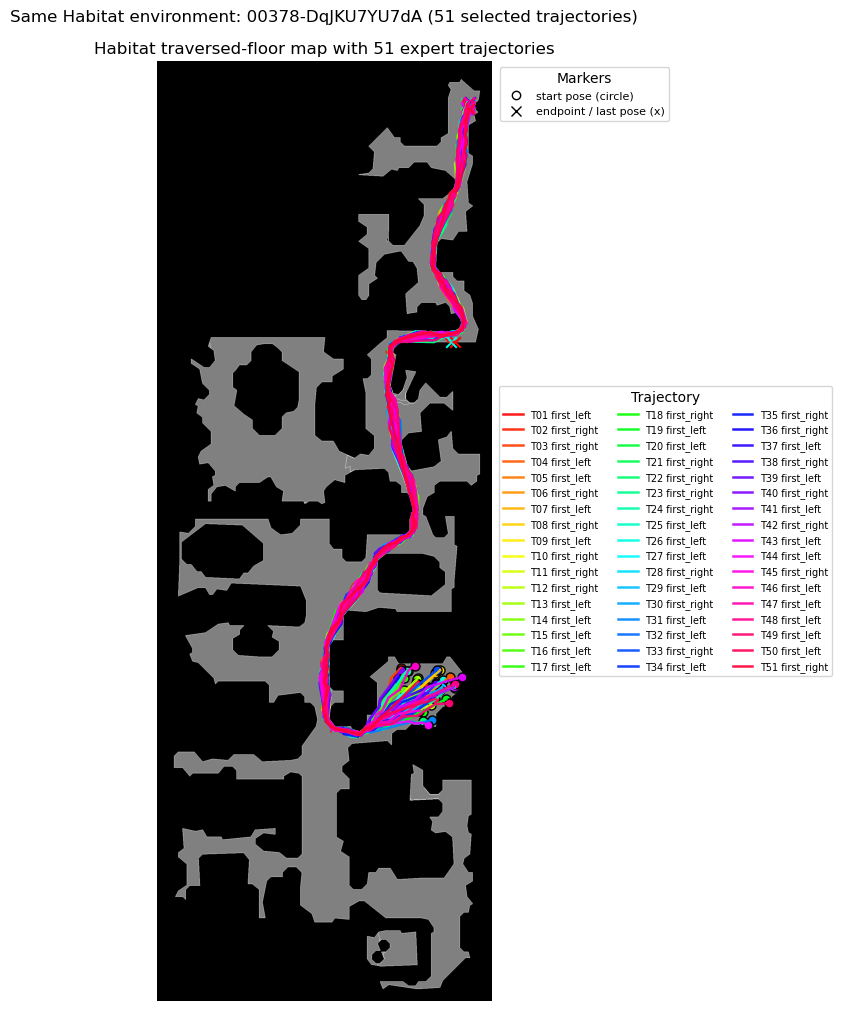

In [2]:
replay = replay_habitat_topdown(records, data_root=DATA_ROOT)
fig, ax = plot_habitat_topdown(replay)
plt.show()


읽는 방법: 같은 색과 `Txx` label이 한 expert trajectory입니다. 원형 marker는 start pose, `x` marker는 endpoint / last pose입니다. 여기서 branch처럼 보이는 구조가 latent space에서도 보존되는지가 다음 두 notebook의 질문입니다.